# Task 4 — Part 2: Decision Tree & Random Forest Regression
**Датасет:** `housing.csv` (Калифорнийская жилая недвижимость, 20 640 домов)  
**Цель:** предсказать `median_house_value` (стоимость жилья)

## 1. Импорты

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Загрузка данных и EDA

In [3]:
df = pd.read_csv('housing.csv')
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
print("Пропущенные значения:")
print(df.isnull().sum())

Пропущенные значения:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


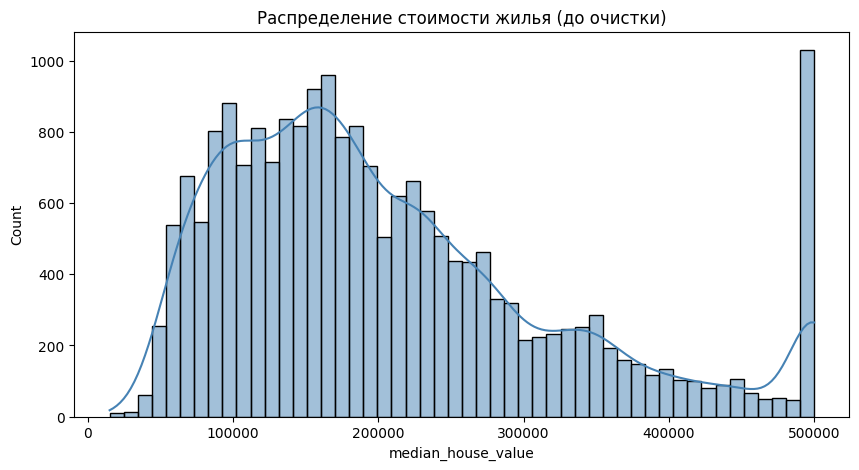

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='steelblue')
plt.title('Распределение стоимости жилья (до очистки)')
plt.xlabel('median_house_value')
plt.show()

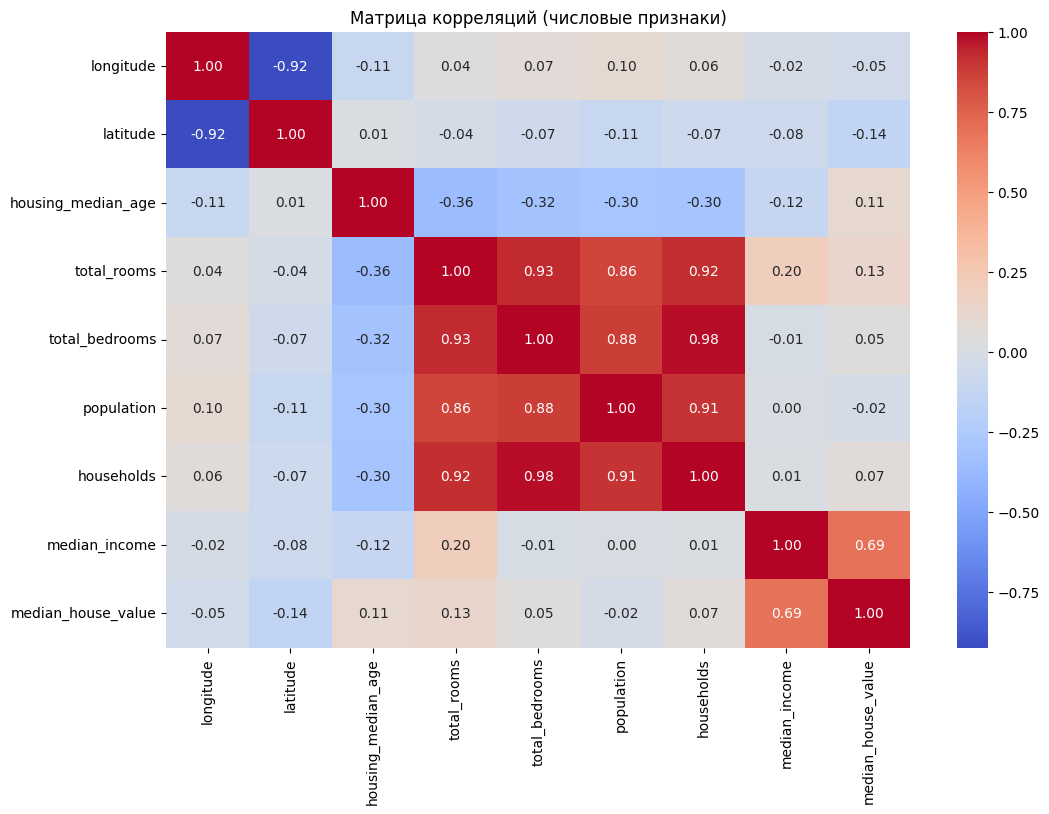

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляций (числовые признаки)')
plt.show()

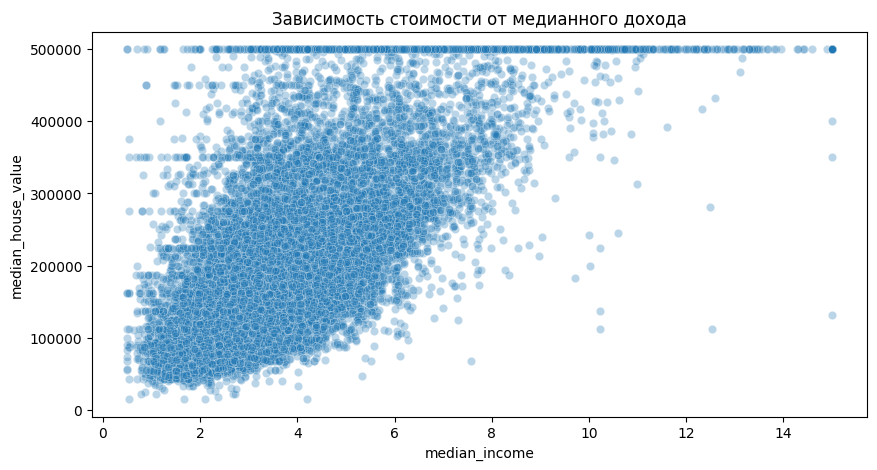

In [9]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.3)
plt.title('Зависимость стоимости от медианного дохода')
plt.show()

/tmp/ipykernel_446487/3857105162.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', palette='Set2')


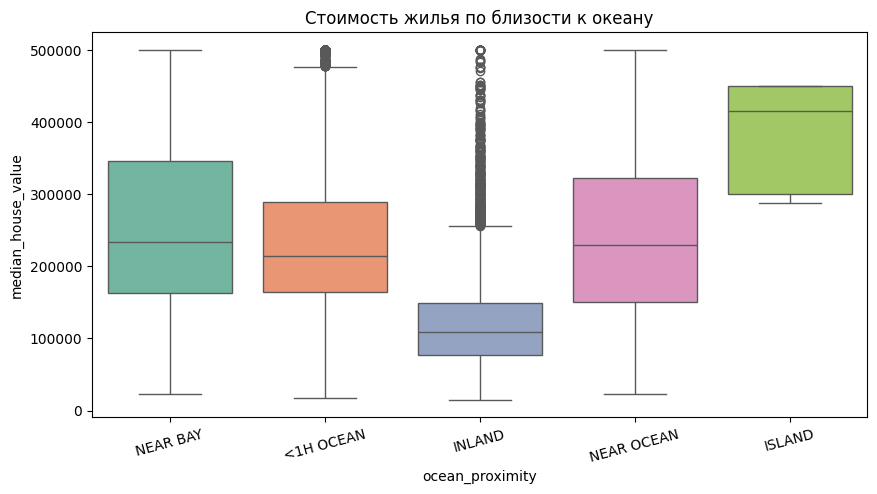

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', palette='Set2')
plt.title('Стоимость жилья по близости к океану')
plt.xticks(rotation=15)
plt.show()

## 3. Предобработка данных

In [11]:
# Заполняем 207 пропусков в total_bedrooms медианой
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# One-hot encoding категориального признака ocean_proximity
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df = df.astype(float)

print("После кодирования — новые колонки:", list(df.columns))

После кодирования — новые колонки: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [12]:
# Feature engineering: создаём более информативные признаки
df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']     / df['households']

# Убираем выбросы: дома с ценой на потолке (500 000 = capped значение в данных)
df = df[df['median_house_value'] < 500_000]

# Исходные «сырые» счётчики теперь заменены производными — удаляем
df = df.drop(columns=['total_rooms', 'total_bedrooms', 'population', 'households'])

print(f"Размер после очистки: {df.shape}")
print(df.isnull().sum())

Размер после очистки: (19648, 12)
longitude                     0
latitude                      0
housing_median_age            0
median_income                 0
median_house_value            0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
rooms_per_household           0
bedrooms_per_room             0
population_per_household      0
dtype: int64


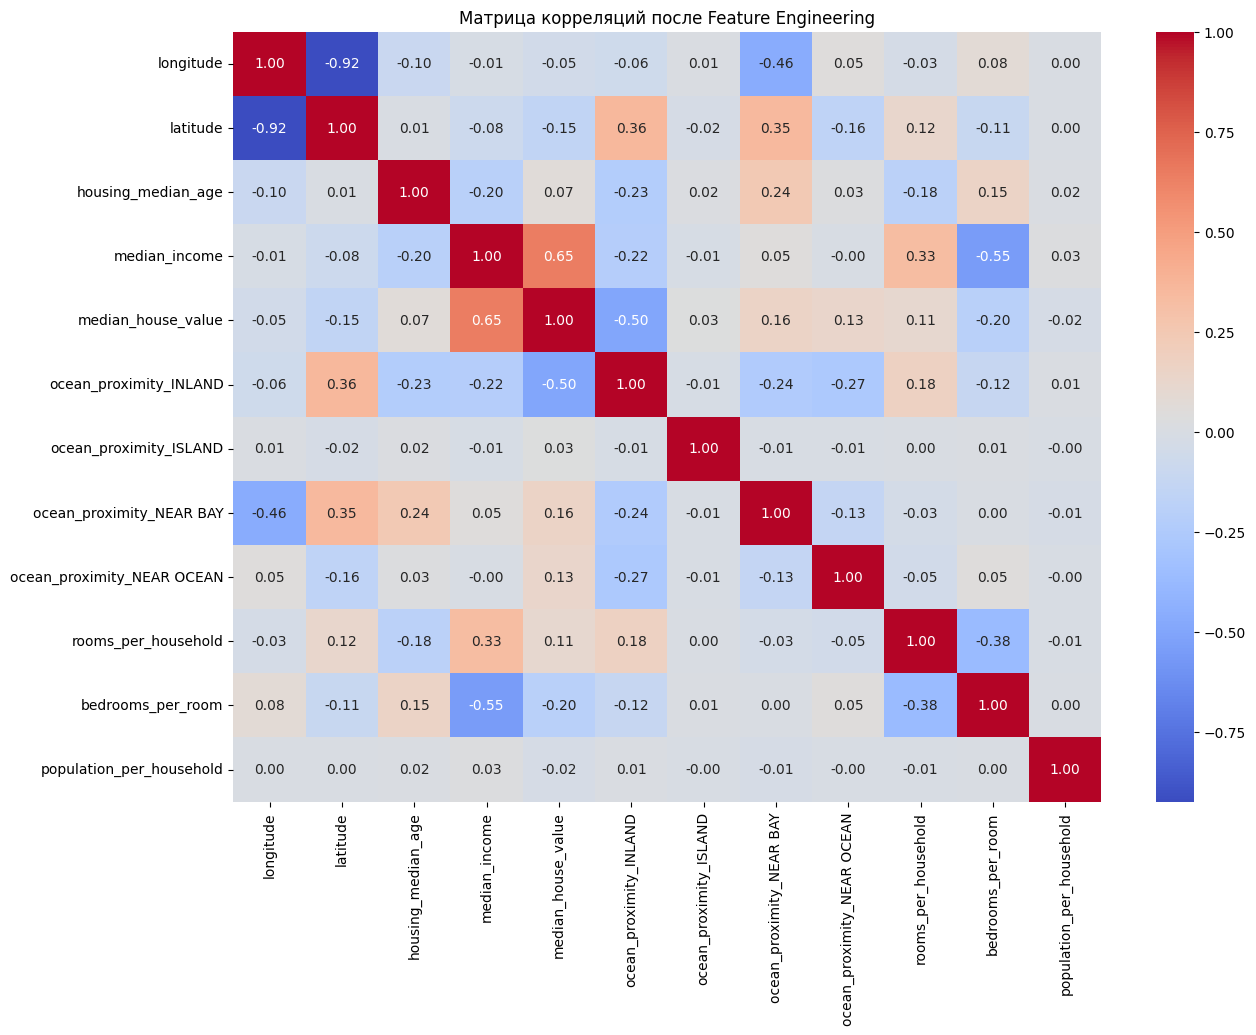

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляций после Feature Engineering')
plt.show()

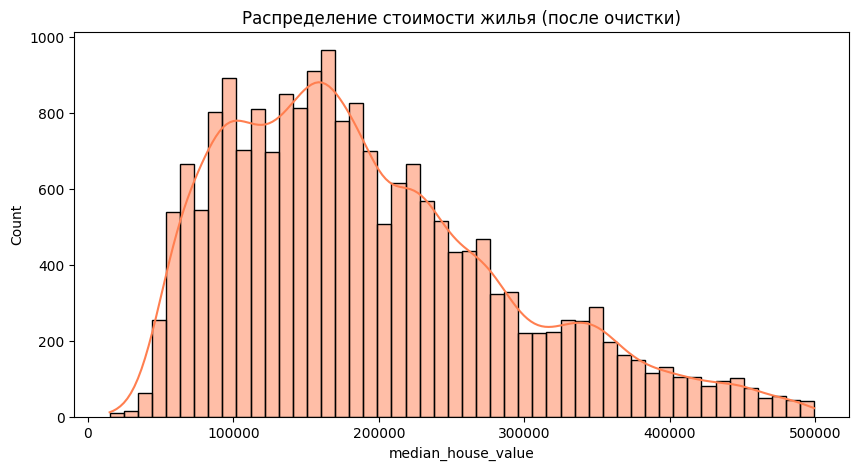

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='coral')
plt.title('Распределение стоимости жилья (после очистки)')
plt.show()

## 4. Разделение данных

> **Почему нет StandardScaler?**  
> Деревья решений и случайный лес делают разбиения по порогу (`median_income > 3.5`), а не по расстоянию.  
> Масштаб признаков на них не влияет — скейлинг не нужен.

In [15]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (15718, 11), Test: (3930, 11)


## 5. Decision Tree Regressor — подбор параметров (GridSearchCV)

In [16]:
param_grid_dt = {
    'max_depth':        [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features':     [None, 'sqrt', 'log2']
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_dt.best_params_}")
print(f"RMSE (CV): {np.sqrt(-grid_dt.best_score_):.2f}")

Лучшие параметры: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 20}
RMSE (CV): 52393.07


/tmp/ipykernel_446487/965616890.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df['param_max_depth'] = results_df['param_max_depth'].fillna(20).astype(int)


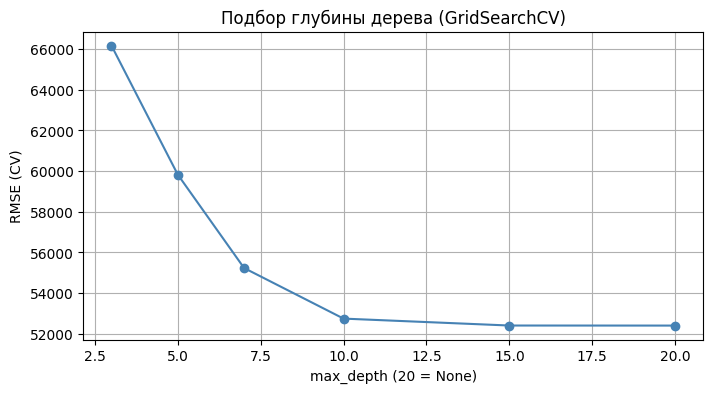

In [17]:
# График RMSE по глубине дерева (берём лучшее по остальным параметрам)
results_df = pd.DataFrame(grid_dt.cv_results_)
# Заменяем None глубины на 20 для корректной отрисовки
results_df['param_max_depth'] = results_df['param_max_depth'].fillna(20).astype(int)
depth_rmse = results_df.groupby('param_max_depth')['mean_test_score'].max().apply(lambda s: np.sqrt(-s))

plt.figure(figsize=(8, 4))
plt.plot(depth_rmse.index, depth_rmse.values, marker='o', color='steelblue')
plt.xlabel('max_depth (20 = None)')
plt.ylabel('RMSE (CV)')
plt.title('Подбор глубины дерева (GridSearchCV)')
plt.grid()
plt.show()

## 6. Decision Tree — оценка модели

In [18]:
dt = grid_dt.best_estimator_
dt_pred = dt.predict(X_test)

dt_mae  = mean_absolute_error(y_test, dt_pred)
dt_mse  = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2   = r2_score(y_test, dt_pred)

print("=== Decision Tree Regressor ===")
print(f"MAE  (Средняя абсолютная ошибка): {dt_mae:>12.2f}")
print(f"MSE  (Среднеквадратичная ошибка): {dt_mse:>12.2f}")
print(f"RMSE (Корень из MSE):             {dt_rmse:>12.2f}")
print(f"R²   (Коэф. детерминации):        {dt_r2:>12.4f}")

=== Decision Tree Regressor ===
MAE  (Средняя абсолютная ошибка):     35854.80
MSE  (Среднеквадратичная ошибка): 2741117701.42
RMSE (Корень из MSE):                 52355.68
R²   (Коэф. детерминации):              0.7141


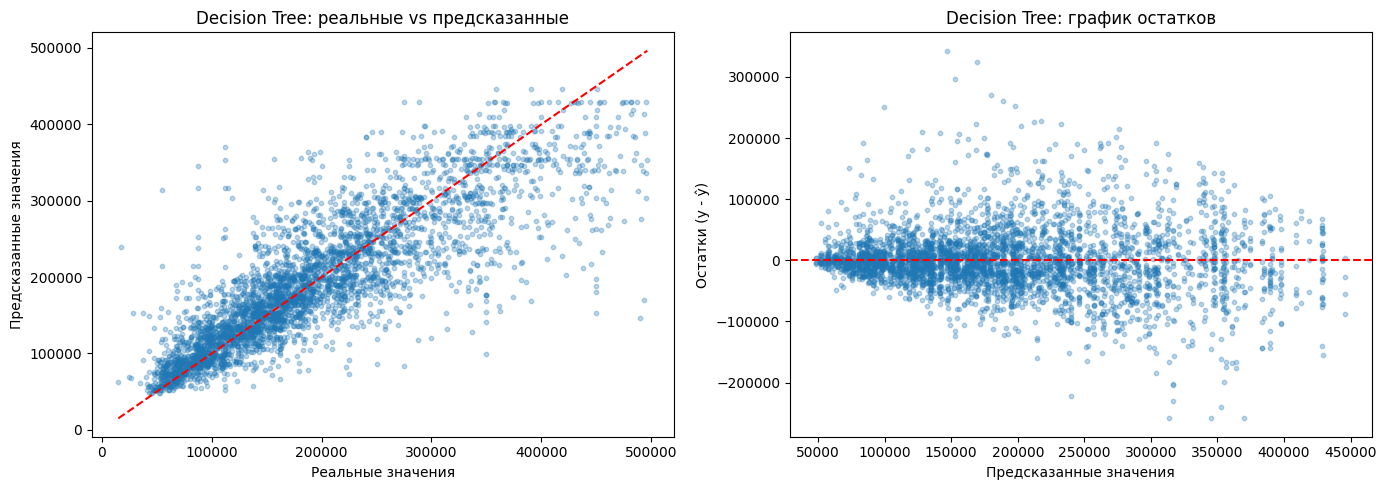

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, dt_pred, alpha=0.3, s=10)
lim = [y_test.min(), y_test.max()]
ax.plot(lim, lim, 'r--')
ax.set_xlabel('Реальные значения')
ax.set_ylabel('Предсказанные значения')
ax.set_title('Decision Tree: реальные vs предсказанные')

# 2) Residuals
residuals_dt = y_test - dt_pred
ax2 = axes[1]
ax2.scatter(dt_pred, residuals_dt, alpha=0.3, s=10)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('Предсказанные значения')
ax2.set_ylabel('Остатки (y - ŷ)')
ax2.set_title('Decision Tree: график остатков')

plt.tight_layout()
plt.show()

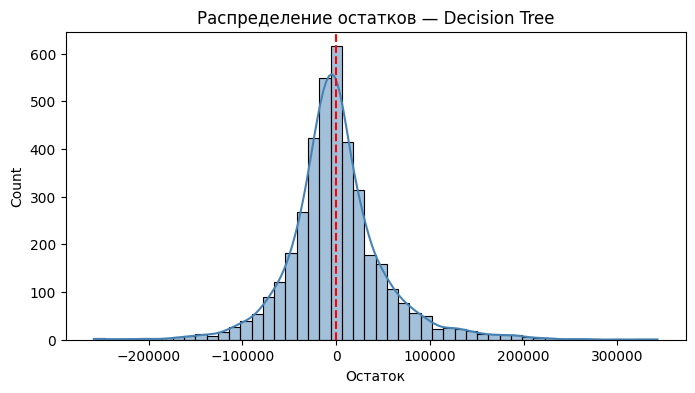

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(residuals_dt, bins=50, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Распределение остатков — Decision Tree')
plt.xlabel('Остаток')
plt.show()

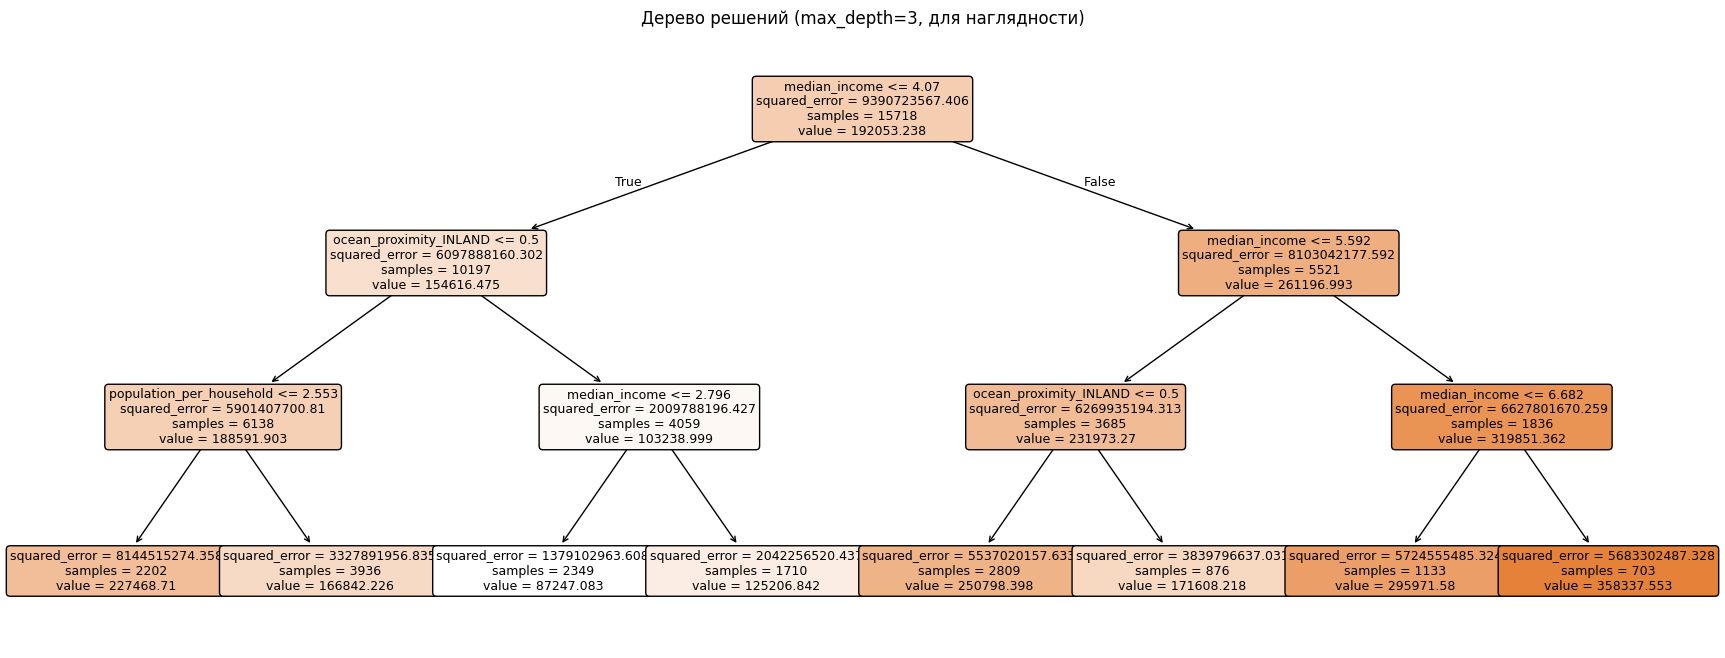

In [21]:
# Визуализация структуры дерева (глубина 3 для читаемости)
dt_vis = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_vis.fit(X_train, y_train)

plt.figure(figsize=(22, 8))
plot_tree(
    dt_vis,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Дерево решений (max_depth=3, для наглядности)')
plt.show()

## 7. Random Forest Regressor — подбор числа деревьев (GridSearchCV)

Лучшее количество деревьев: 300
RMSE (CV): 44576.67


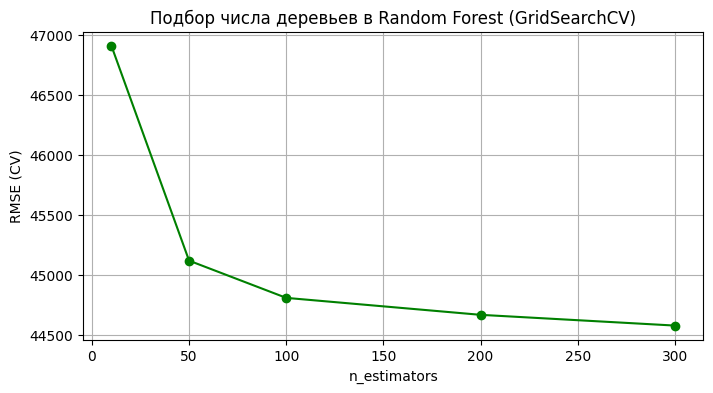

In [23]:
param_grid_rf = {'n_estimators': [10, 50, 100, 200, 300]}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

best_n = grid_rf.best_params_['n_estimators']
print(f"Лучшее количество деревьев: {best_n}")
print(f"RMSE (CV): {np.sqrt(-grid_rf.best_score_):.2f}")

# График RMSE по числу деревьев
n_estimators_vals = param_grid_rf['n_estimators']
cv_rmse = [np.sqrt(-s) for s in grid_rf.cv_results_['mean_test_score']]

plt.figure(figsize=(8, 4))
plt.plot(n_estimators_vals, cv_rmse, marker='o', color='green')
plt.xlabel('n_estimators')
plt.ylabel('RMSE (CV)')
plt.title('Подбор числа деревьев в Random Forest (GridSearchCV)')
plt.grid()
plt.show()

## 8. Random Forest — оценка модели

In [24]:
rf = grid_rf.best_estimator_
rf_pred = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_mse  = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2   = r2_score(y_test, rf_pred)

print("=== Random Forest Regressor ===")
print(f"MAE  (Средняя абсолютная ошибка): {rf_mae:>12.2f}")
print(f"MSE  (Среднеквадратичная ошибка): {rf_mse:>12.2f}")
print(f"RMSE (Корень из MSE):             {rf_rmse:>12.2f}")
print(f"R²   (Коэф. детерминации):        {rf_r2:>12.4f}")

=== Random Forest Regressor ===
MAE  (Средняя абсолютная ошибка):     30543.00
MSE  (Среднеквадратичная ошибка): 2124835707.88
RMSE (Корень из MSE):                 46095.94
R²   (Коэф. детерминации):              0.7784


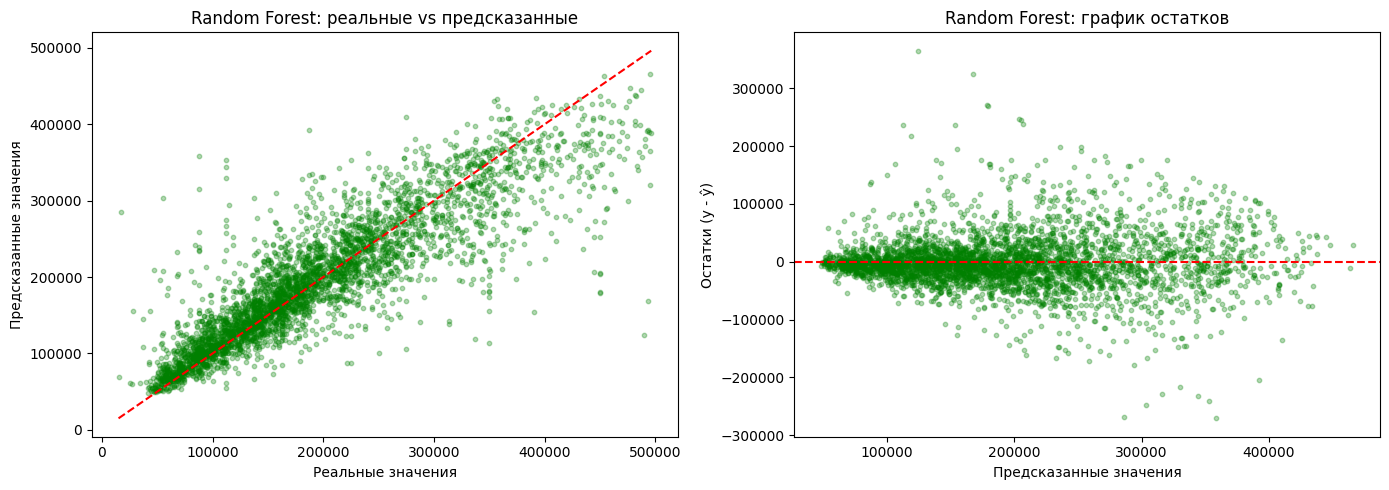

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test, rf_pred, alpha=0.3, s=10, color='green')
lim = [y_test.min(), y_test.max()]
ax.plot(lim, lim, 'r--')
ax.set_xlabel('Реальные значения')
ax.set_ylabel('Предсказанные значения')
ax.set_title('Random Forest: реальные vs предсказанные')

residuals_rf = y_test - rf_pred
ax2 = axes[1]
ax2.scatter(rf_pred, residuals_rf, alpha=0.3, s=10, color='green')
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('Предсказанные значения')
ax2.set_ylabel('Остатки (y - ŷ)')
ax2.set_title('Random Forest: график остатков')

plt.tight_layout()
plt.show()

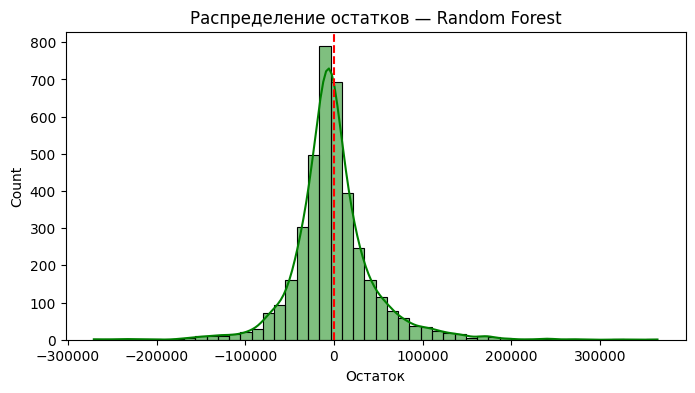

In [26]:
plt.figure(figsize=(8, 4))
sns.histplot(residuals_rf, bins=50, kde=True, color='green')
plt.axvline(0, color='red', linestyle='--')
plt.title('Распределение остатков — Random Forest')
plt.xlabel('Остаток')
plt.show()

## 9. Важность признаков (Feature Importance)

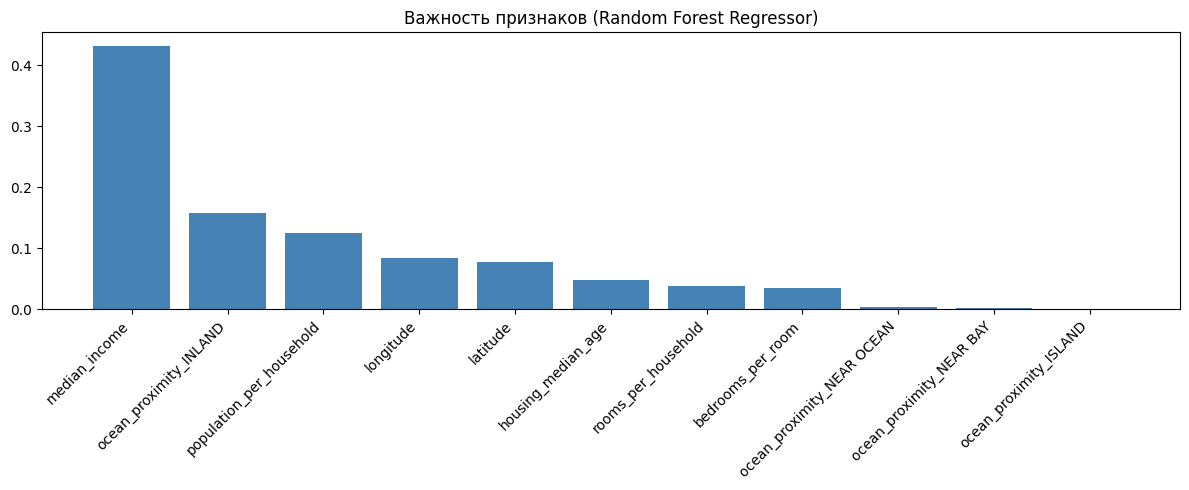


Самый важный признак: 'median_income'  (важность = 0.4322)

Рейтинг всех признаков:
   1. median_income                       0.4322
   2. ocean_proximity_INLAND              0.1569
   3. population_per_household            0.1242
   4. longitude                           0.0841
   5. latitude                            0.0777
   6. housing_median_age                  0.0477
   7. rooms_per_household                 0.0378
   8. bedrooms_per_room                   0.0343
   9. ocean_proximity_NEAR OCEAN          0.0037
  10. ocean_proximity_NEAR BAY            0.0013
  11. ocean_proximity_ISLAND              0.0002


In [27]:
importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha='right')
plt.title('Важность признаков (Random Forest Regressor)')
plt.tight_layout()
plt.show()

print(f"\nСамый важный признак: '{feature_names[indices[0]]}'  (важность = {importances[indices[0]]:.4f})")
print("\nРейтинг всех признаков:")
for rank, idx in enumerate(indices, 1):
    print(f"  {rank:2d}. {feature_names[idx]:<35} {importances[idx]:.4f}")

## 10. Сравнение моделей

In [28]:
comparison = pd.DataFrame({
    'Модель': ['Decision Tree', 'Random Forest'],
    'MAE':    [dt_mae,  rf_mae],
    'MSE':    [dt_mse,  rf_mse],
    'RMSE':   [dt_rmse, rf_rmse],
    'R²':     [dt_r2,   rf_r2]
})
comparison = comparison.set_index('Модель')
comparison.style.format('{:.2f}').highlight_min(axis=0, color='lightgreen')

,MAE,MSE,RMSE,R²
Модель,,,,
Decision Tree,35854.80,2741117701.42,52355.68,0.71
Random Forest,30543.00,2124835707.88,46095.94,0.78


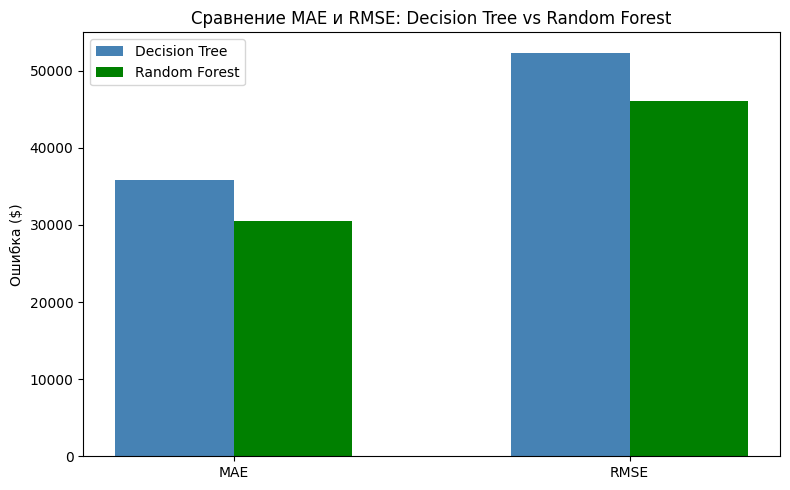

In [29]:
metrics = ['MAE', 'RMSE']
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, [dt_mae, dt_rmse], width, label='Decision Tree', color='steelblue')
ax.bar(x + width/2, [rf_mae, rf_rmse], width, label='Random Forest', color='green')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Ошибка ($)')
ax.set_title('Сравнение MAE и RMSE: Decision Tree vs Random Forest')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Предсказание стоимости нового дома

In [30]:
# Новый дом: longitude, latitude, housing_median_age, median_income,
# ocean_proximity_INLAND, ocean_proximity_ISLAND, ocean_proximity_NEAR BAY,
# ocean_proximity_NEAR OCEAN, rooms_per_household, bedrooms_per_room, population_per_household

new_house = {
    'longitude':                   -118.5,
    'latitude':                      34.0,
    'housing_median_age':            20.0,
    'median_income':                  5.0,
    'ocean_proximity_INLAND':         0.0,
    'ocean_proximity_ISLAND':         0.0,
    'ocean_proximity_NEAR BAY':       0.0,
    'ocean_proximity_NEAR OCEAN':     1.0,
    'rooms_per_household':            5.5,
    'bedrooms_per_room':              0.18,
    'population_per_household':       2.8
}

new_house_df = pd.DataFrame([new_house], columns=X.columns)

dt_new  = dt.predict(new_house_df)[0]
rf_new  = rf.predict(new_house_df)[0]

print(f"Decision Tree  — прогноз стоимости: ${dt_new:,.0f}")
print(f"Random Forest  — прогноз стоимости: ${rf_new:,.0f}")

Decision Tree  — прогноз стоимости: $302,045
Random Forest  — прогноз стоимости: $299,410
